# Progetto di Linguistica Computazionale II - Matilde Viti
# Task 1: Classificatore   basato   su   Support   Vector   Machine   (SVM)   lineari   e informazioni linguistiche non lessicali (Profiling-UD)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.dummy import DummyClassifier

from support_task1 import (
    build_profiling_input,
    load_profiling_output,
    split_dataset
)

 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
build_profiling_input(  
    train_path="train.csv",
    validation_path="validation.csv",
    test_path="test.csv",
    input_dir="profiling_input",
    paragraph_info_path="paragraph_info.json"
)

{'train_p00000': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00001': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00002': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00003': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00004': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00005': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00006': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00007': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00008': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00009': {'author': 'Charlotte Bronte',
  'book_id': 'CB-BOOK2',
  'split': 'train'},
 'train_p00010': {'author': 'Charlotte Bronte',
  'book_id':

Zippo cartella con zip -r profiling_input.zip profiling_input nel terminale...

In [4]:
feature_names, dataset = load_profiling_output(
    profiling_output_path="19181.csv", # inserisco nome del file di output generato da profiling_ud, (cambiare manualmente se ricarico un altro file da capo)
    paragraph_info_path="paragraph_info.json"
)

print("Numero feature:", len(feature_names))
print("Prime 10 feature:", feature_names[:10])

first_id = list(dataset.keys())[0]
print(first_id)
print(dataset[first_id])

Numero feature: 127
Prime 10 feature: ['n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'ttr_lemma_chunks_100', 'ttr_form_chunks_100', 'upos_dist_ADJ', 'upos_dist_ADP', 'upos_dist_ADV', 'upos_dist_AUX']
train_p00000
{'author': 'Charlotte Bronte', 'book_id': 'CB-BOOK2', 'split': 'train', 'features': [3.0, 111.0, 37.0, 3.9473684210526314, 0.0, 0.0, 12.612612612612613, 11.711711711711711, 4.504504504504505, 8.108108108108109, 3.6036036036036037, 8.108108108108109, 0.0, 16.216216216216218, 0.9009009009009009, 3.6036036036036037, 6.306306306306307, 0.9009009009009009, 14.414414414414415, 0.0, 0.0, 9.00900900900901, 0.0, 0.5052631578947369, 33.333333333333336, 66.66666666666667, 50.0, 50.0, 40.0, 0.0, 20.0, 40.0, 75.0, 0.0, 0.0, 25.0, 0.0, 100.0, 0.0, 100.0, 77.77777777777777, 0.0, 22.22222222222222, 0.0, 85.71428571428571, 0.0, 0.0, 14.285714285714286, 4.333333333333333, 100.0, 2.4, 11.11111111111111, 0.0, 33.333333333333336, 33.333333333333336, 11.11111111111111, 11.1111111111

### Split dei paragrafi relativi al training, al validation e al test set

In [5]:
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(dataset, target_label="author")

print("Train:", len(X_train), len(y_train))
print("Validation:", len(X_val), len(y_val))
print("Test:", len(X_test), len(y_test))

Train: 4312 4312
Validation: 600 600
Test: 594 594


In [6]:
X_train = np.array(X_train) # Convertiamo le liste in array numpy
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (4312, 127) (4312,)
Validation: (600, 127) (600,)
Test: (594, 127) (594,)


# 5-fold Cross Validation

In [7]:
# Pipeline del modello
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", LinearSVC(
        C=1.0,
        class_weight="balanced", 
        dual=False,
        max_iter=10000,
        random_state=42 
    ))
])

# ==========================
# 1. Cross-validation (5-fold)
# ==========================

y_pred_cv = cross_val_predict(
    pipeline,
    X_train,
    y_train,
    cv=5
)

print("\nCross-validated classification report:")
print(classification_report(y_train, y_pred_cv))


Cross-validated classification report:
                  precision    recall  f1-score   support

Charlotte Bronte       0.65      0.65      0.65      1436
    George Eliot       0.67      0.65      0.66      1783
     Jane Austen       0.57      0.59      0.58      1093

        accuracy                           0.64      4312
       macro avg       0.63      0.63      0.63      4312
    weighted avg       0.64      0.64      0.64      4312



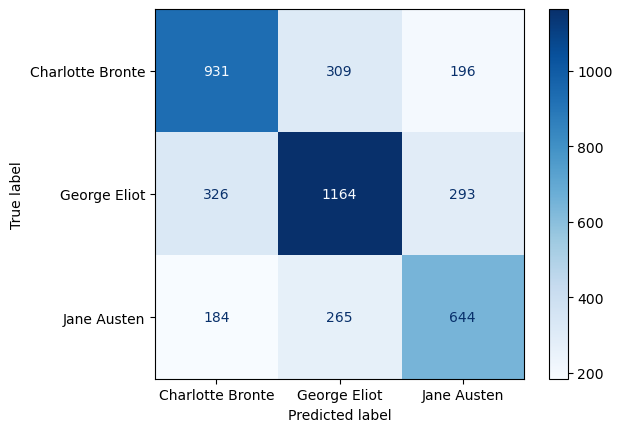

In [20]:
# Confusion matrix per cross-validation
cm_cv = confusion_matrix(y_train, y_pred_cv)
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=["Charlotte Bronte", "George Eliot", "Jane Austen"])
disp_cv.plot(cmap=plt.cm.Blues)

# Applicazione e valutazione sul validation set


In [8]:
# 2. Training finale

print("\nTraining final model on full training set...")
pipeline.fit(X_train, y_train) # addestra il modello su tutto il training set


# 3. Validation

y_val_pred = pipeline.predict(X_val)

print("\n--- Validation Results ---")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Validation F1-macro: {f1_score(y_val, y_val_pred, average='macro'):.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))



Training final model on full training set...

--- Validation Results ---
Validation Accuracy: 0.6950
Validation F1-macro: 0.6934

Classification Report (Validation):
                  precision    recall  f1-score   support

Charlotte Bronte       0.68      0.77      0.72       200
    George Eliot       0.65      0.73      0.69       200
     Jane Austen       0.77      0.58      0.67       200

        accuracy                           0.69       600
       macro avg       0.70      0.69      0.69       600
    weighted avg       0.70      0.69      0.69       600



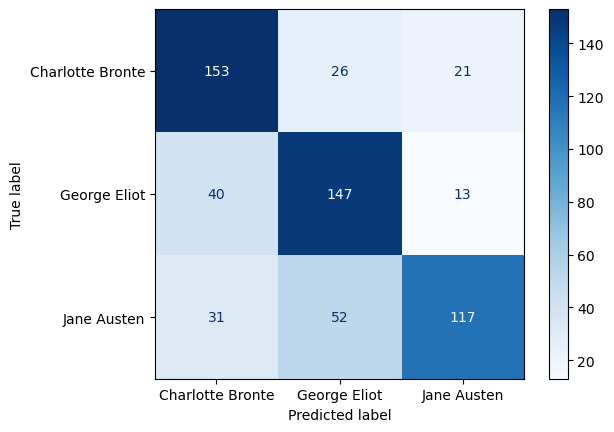

In [18]:
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Charlotte Bronte", "George Eliot", "Jane Austen"]
)
disp_val.plot(cmap=plt.cm.Blues)

# Applicazione e valutazione sul Test set

In [9]:
y_test_pred = pipeline.predict(X_test)

print("\n--- Test Results ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test F1-macro: {f1_score(y_test, y_test_pred, average='macro'):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))


--- Test Results ---
Test Accuracy: 0.6785
Test F1-macro: 0.6777

Classification Report (Test):
                  precision    recall  f1-score   support

Charlotte Bronte       0.67      0.66      0.66       194
    George Eliot       0.64      0.76      0.69       200
     Jane Austen       0.74      0.62      0.68       200

        accuracy                           0.68       594
       macro avg       0.68      0.68      0.68       594
    weighted avg       0.68      0.68      0.68       594



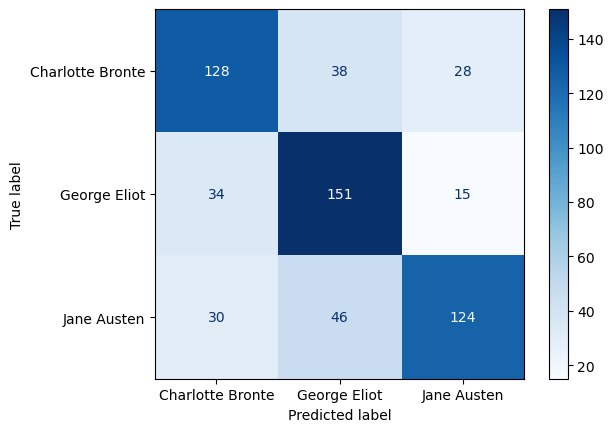

In [19]:
# Confusion Matrix del test set
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Charlotte Bronte", "George Eliot", "Jane Austen"])
disp.plot(cmap=plt.cm.Blues)

# DummyClassifier

In [10]:
baseline_classifier = DummyClassifier(strategy="uniform", random_state=42)
baseline_classifier.fit(X_train, y_train)
baseline_test_predictions = baseline_classifier.predict(X_test)
print("--- Dummy Classifier Baseline ---")
print(classification_report(y_test, baseline_test_predictions, zero_division=0))

--- Dummy Classifier Baseline ---
                  precision    recall  f1-score   support

Charlotte Bronte       0.31      0.34      0.32       194
    George Eliot       0.34      0.33      0.33       200
     Jane Austen       0.30      0.29      0.29       200

        accuracy                           0.32       594
       macro avg       0.32      0.32      0.32       594
    weighted avg       0.32      0.32      0.32       594



# Feature più importanti per classe


Top 20 features per la classe: Charlotte Bronte
                    feature  coefficient
            upos_dist_PUNCT    -1.179751
             dep_dist_punct     1.168942
             upos_dist_NOUN     0.506134
            lexical_density    -0.398485
              upos_dist_ADV     0.343576
                dep_dist_cc    -0.332651
              upos_dist_ADJ     0.286489
            dep_dist_advmod    -0.258816
              dep_dist_case    -0.243573
               dep_dist_aux    -0.234345
              dep_dist_mark    -0.202590
avg_prepositional_chain_len    -0.201493
            upos_dist_CCONJ     0.200395
              dep_dist_amod    -0.198709
             upos_dist_VERB     0.190094
                prep_dist_2     0.188166
               dep_dist_cop    -0.169676
  verbs_num_pers_dist_Sing+    -0.158808
                prep_dist_1     0.158271
        aux_tense_dist_Pres     0.129700


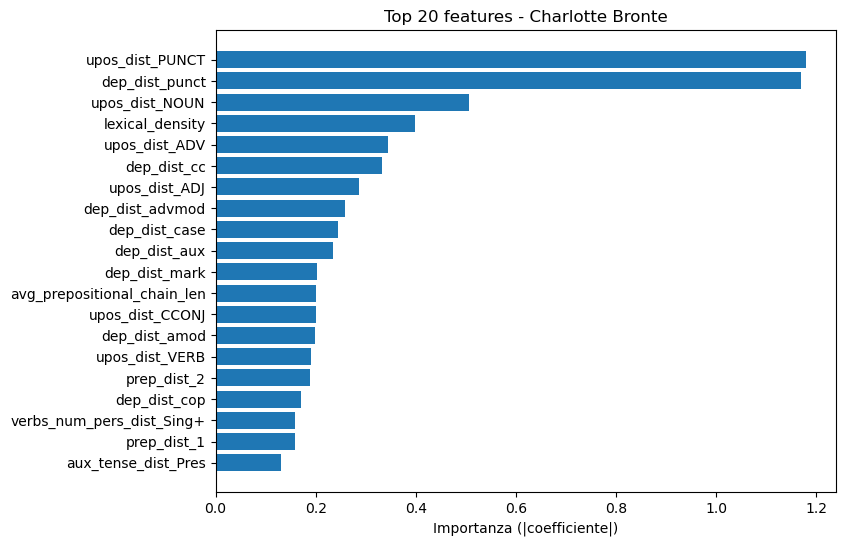


Top 20 features per la classe: George Eliot
                    feature  coefficient
            lexical_density     0.786286
                dep_dist_cc     0.445024
avg_prepositional_chain_len     0.405195
                prep_dist_2    -0.402456
              upos_dist_ADV    -0.357259
        ttr_form_chunks_100     0.354299
                prep_dist_1    -0.351881
              dep_dist_conj    -0.330995
       ttr_lemma_chunks_100    -0.312583
             upos_dist_PRON     0.305116
              upos_dist_ADP     0.284653
               char_per_tok    -0.280315
              upos_dist_AUX     0.230553
            upos_dist_CCONJ    -0.227599
            upos_dist_PUNCT    -0.225503
         dep_dist_discourse     0.213860
              upos_dist_ADJ    -0.213749
              dep_dist_flat    -0.207613
                upos_dist_X     0.191404
             dep_dist_nsubj    -0.184252


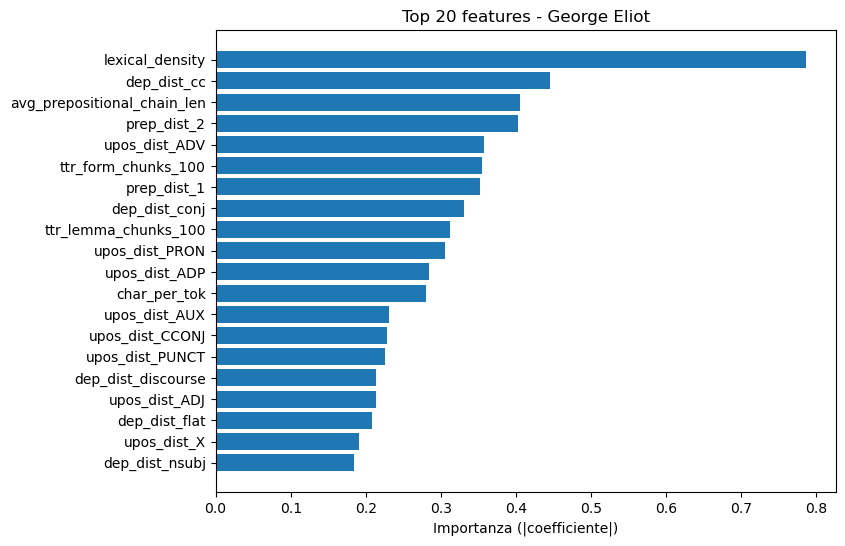


Top 20 features per la classe: Jane Austen
                    feature  coefficient
            upos_dist_PUNCT     1.257994
             dep_dist_punct    -1.096535
            lexical_density    -0.668173
             upos_dist_PRON    -0.503146
                upos_dist_X    -0.341165
        ttr_form_chunks_100    -0.311271
              upos_dist_ADP    -0.308389
               char_per_tok     0.281904
       ttr_lemma_chunks_100     0.271372
             upos_dist_NOUN    -0.264680
          dep_dist_goeswith    -0.249878
            dep_dist_advmod     0.240384
             dep_dist_nsubj     0.228173
                prep_dist_2     0.216676
avg_prepositional_chain_len    -0.213456
              dep_dist_conj     0.210163
                n_sentences     0.204756
              dep_dist_flat     0.203260
                prep_dist_1     0.202208
         dep_dist_nmod:poss     0.194845


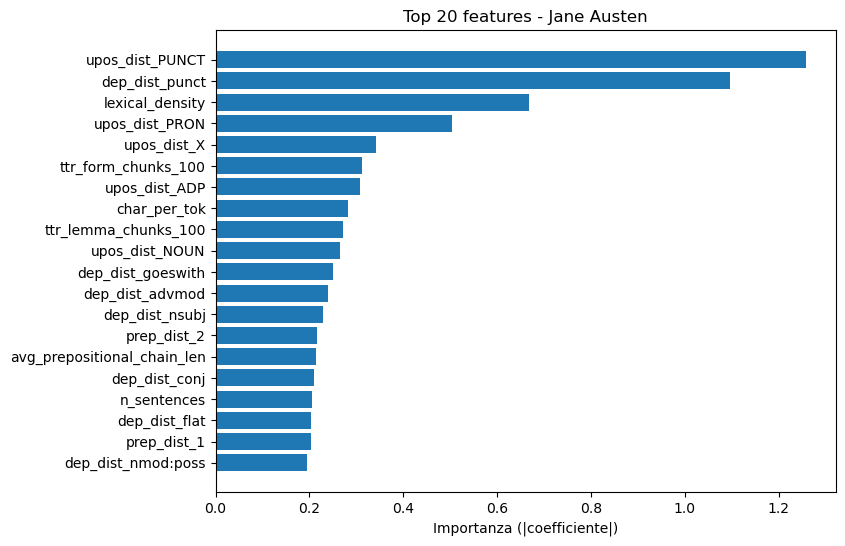

In [11]:
# ==========================
# 6. Feature più importanti per ciascuna classe
# ==========================

svc = pipeline.named_steps["svc"]
coefs = svc.coef_

for idx, class_name in enumerate(svc.classes_):
    class_coefs = coefs[idx]

    feature_importances = pd.DataFrame({
        "feature": feature_names,
        "coefficient": class_coefs,
        "abs_coefficient": np.abs(class_coefs)
    }).sort_values("abs_coefficient", ascending=False)

    print(f"\nTop 20 features per la classe: {class_name}")
    print(feature_importances[["feature", "coefficient"]].head(20).to_string(index=False))
    
    top_features = feature_importances.head(20)

    plt.figure(figsize=(8, 6))
    plt.barh(top_features["feature"], top_features["abs_coefficient"])
    plt.gca().invert_yaxis()
    plt.title(f"Top 20 features - {class_name}")
    plt.xlabel("Importanza (|coefficiente|)")
    plt.show()

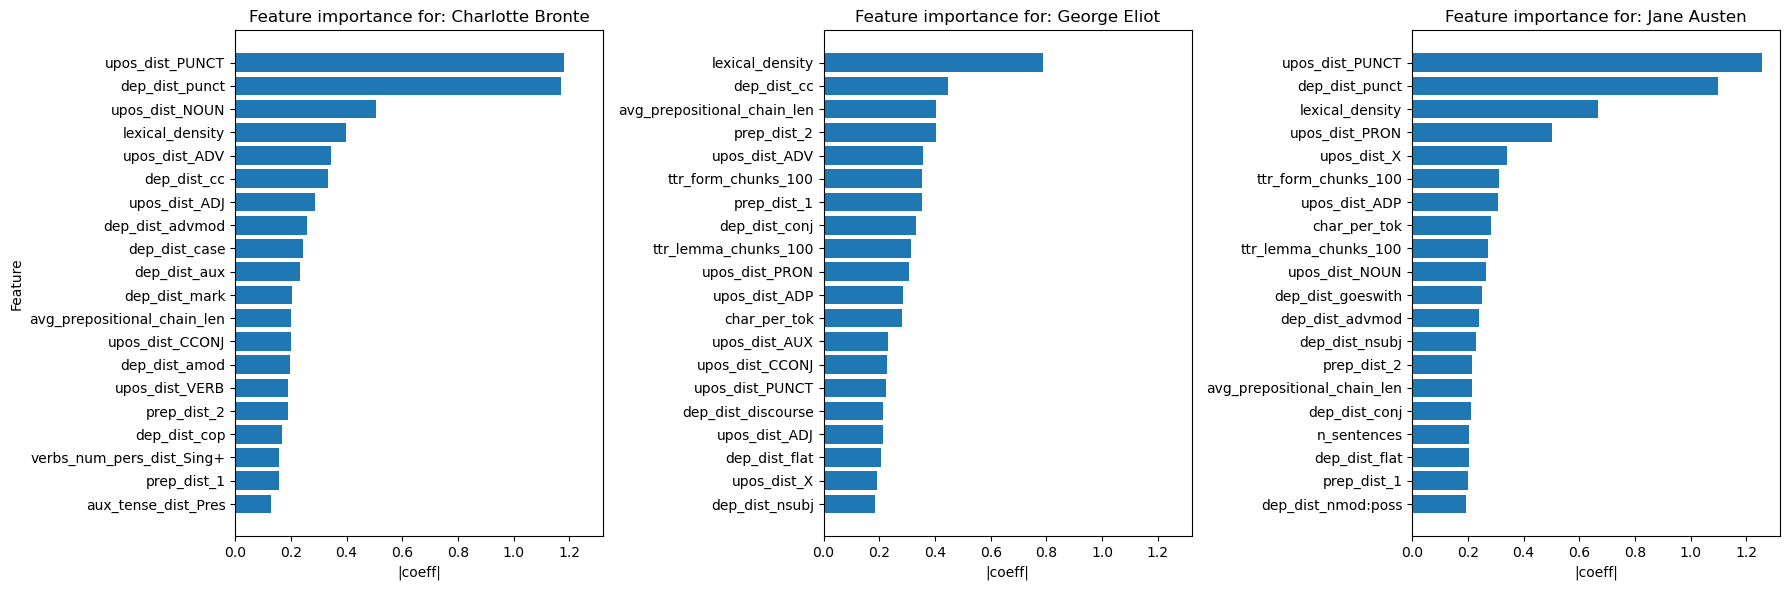

In [12]:
# ==========================
# 6. Feature più importanti per ciascuna classe (grafico unico) (per copiarlo su progetto LaTex)
# ==========================

svc = pipeline.named_steps["svc"]
coefs = svc.coef_

fig, axes = plt.subplots(1, len(svc.classes_), figsize=(18,6), sharex=True)

for idx, class_name in enumerate(svc.classes_):
    class_coefs = coefs[idx]

    feature_importances = pd.DataFrame({
        "feature": feature_names,
        "coefficient": class_coefs,
        "abs_coefficient": np.abs(class_coefs)
    }).sort_values("abs_coefficient", ascending=False)

    top_features = feature_importances.head(20)

    axes[idx].barh(top_features["feature"], top_features["abs_coefficient"])
    axes[idx].invert_yaxis()


    axes[idx].set_title(f'Feature importance for: {class_name}')
    axes[idx].set_xlabel("|coeff|")

axes[0].set_ylabel("Feature")

plt.tight_layout()
plt.show()

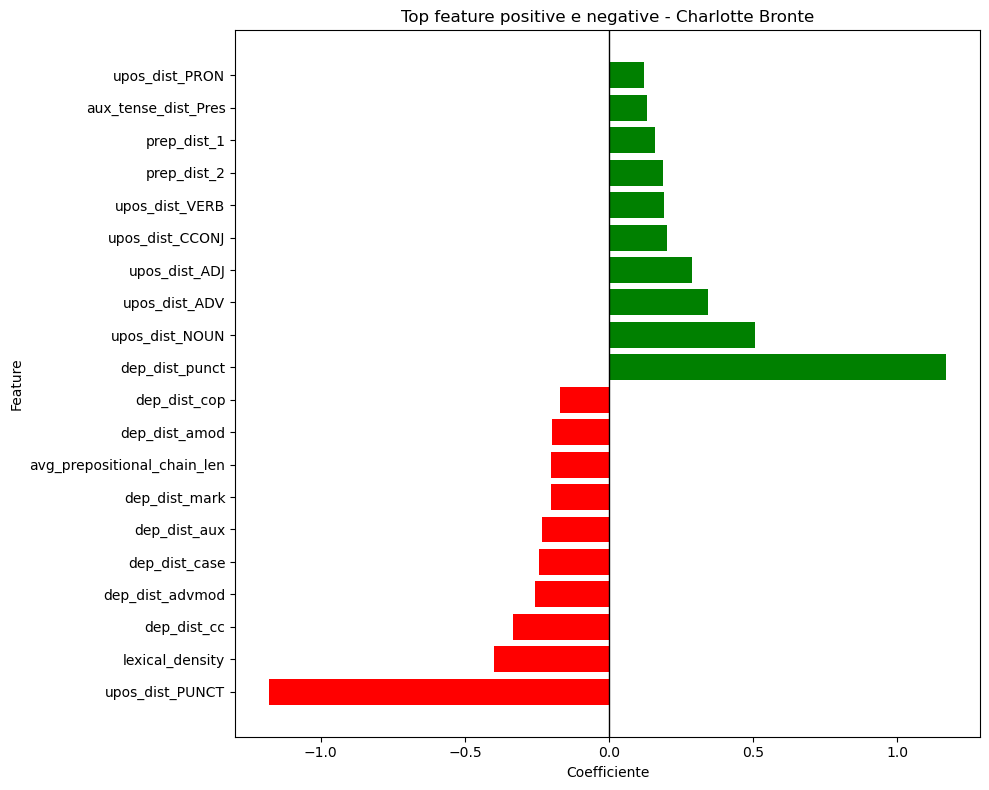

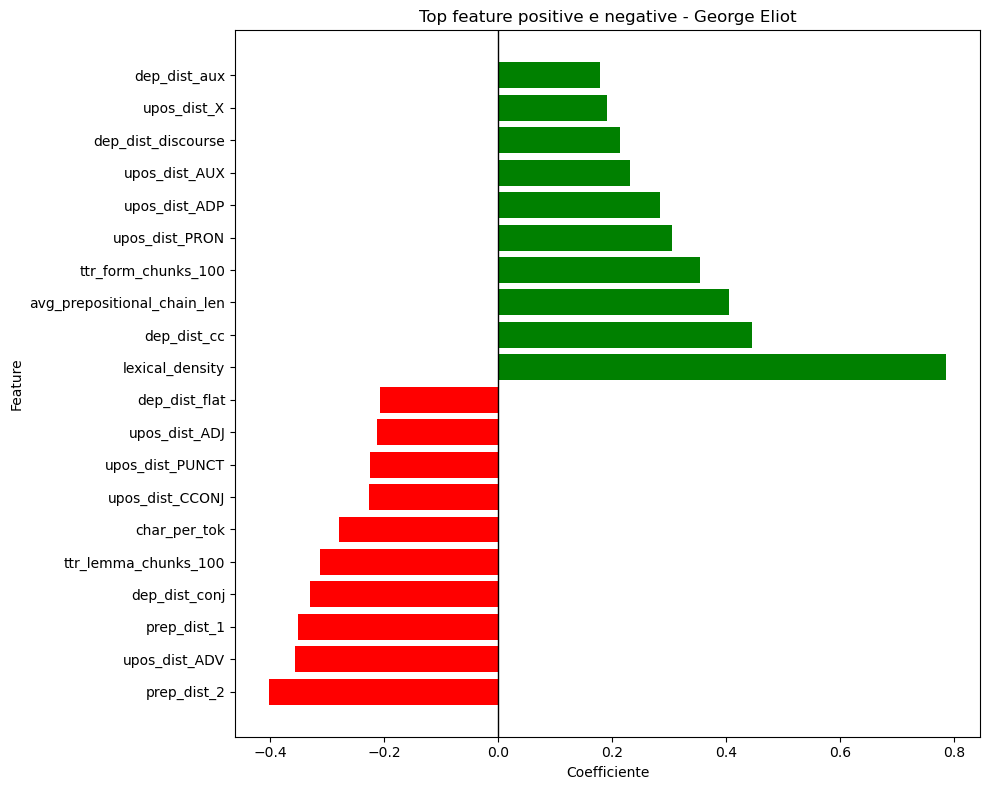

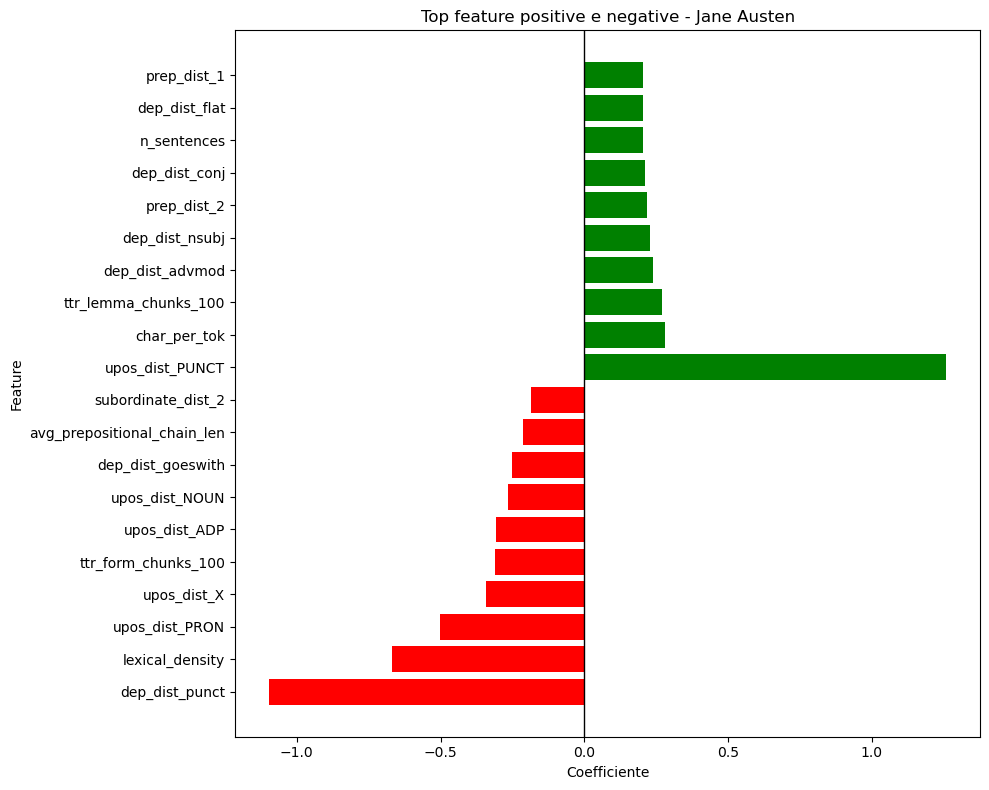

In [13]:
# ==========================
# 6. Grafico feature positive e negative per ogni classe
# ==========================

svc = pipeline.named_steps["svc"]
coefs = svc.coef_

for idx, class_name in enumerate(svc.classes_):
    class_coefs = coefs[idx]

    feat_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": class_coefs
    })

    # 10 feature più positive e 10 più negative
    top_positive = feat_df.sort_values("coefficient", ascending=False).head(10)
    top_negative = feat_df.sort_values("coefficient", ascending=True).head(10)

    # unisco negative + positive
    plot_df = pd.concat([top_negative, top_positive])

    plt.figure(figsize=(10, 8))

    colors = ["green" if c > 0 else "red" for c in plot_df["coefficient"]]

    plt.barh(plot_df["feature"], plot_df["coefficient"], color=colors)

    plt.axvline(0, color="black", linewidth=1)

    plt.title(f"Top feature positive e negative - {class_name}")
    plt.xlabel("Coefficiente")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()